# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

# 2. Load Dataset

In [2]:
df = pd.read_csv("student_data.csv")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# 3. Basic Exploration

In [5]:
print("Shape of Dataset:", df.shape)

df.info()

df.describe()

df.columns

Shape of Dataset: (395, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-nu

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

# 4. Check for missing values

In [6]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

# 5. Exploratory Data Analysis (EDA)

### Distribution of Final Grades

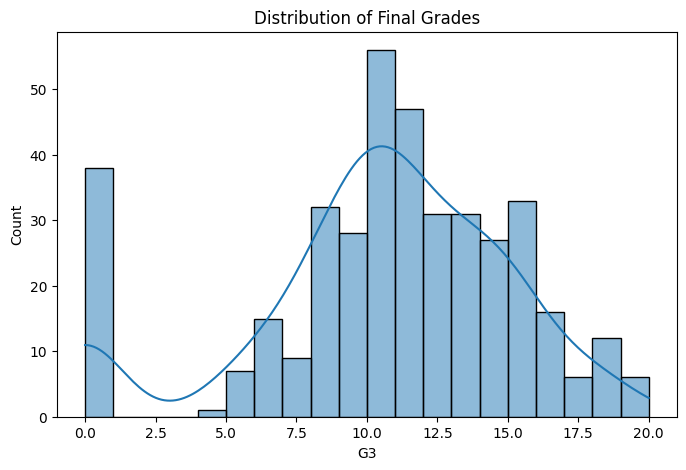

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['G3'], bins=20, kde=True)
plt.title("Distribution of Final Grades")
plt.show()

### Correlation Heatmap

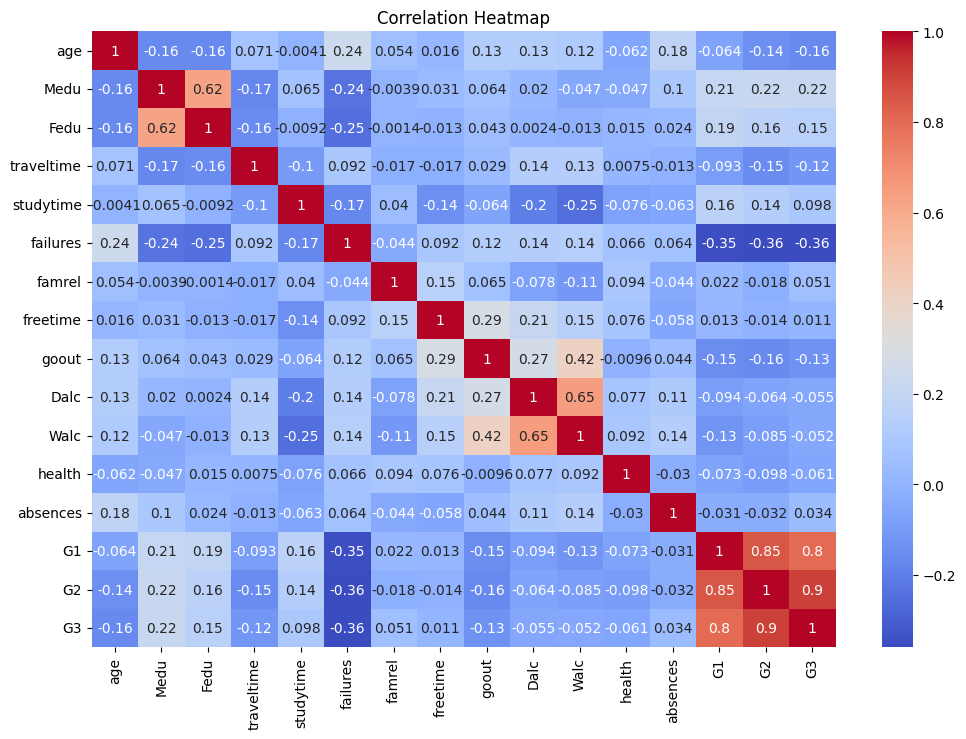

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

### Study Time vs Final Grade

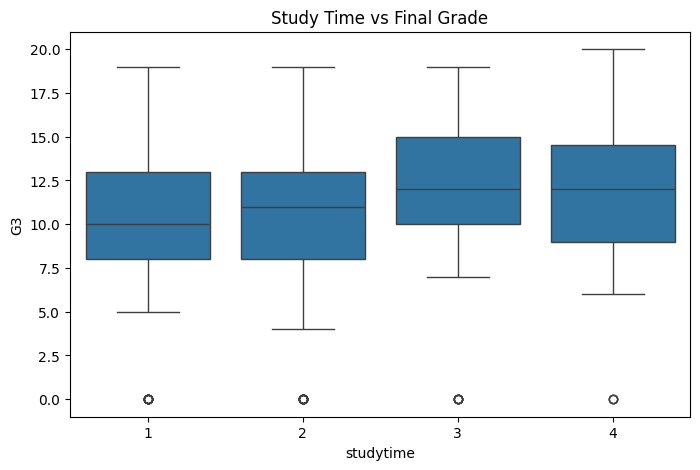

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='studytime',
    y='G3',
    data=df
)

plt.title("Study Time vs Final Grade")
plt.show()

### Absences vs Final Grade

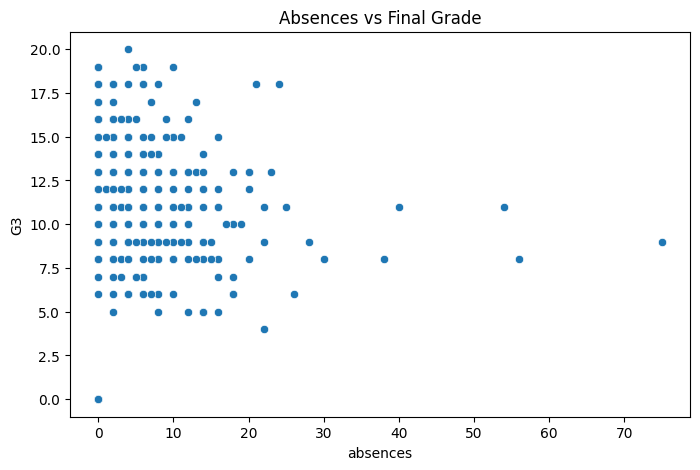

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='absences',
    y='G3',
    data=df
)

plt.title("Absences vs Final Grade")
plt.show()

# 6. Convert Categorical Columns

In [11]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# 7. Check Correlation with Target

In [12]:
correlation = df.corr()

correlation['G3'].sort_values(ascending=False)

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
higher        0.182465
Fedu          0.152457
reason        0.121994
address       0.105756
sex           0.103456
Mjob          0.102082
paid          0.101996
internet      0.098483
studytime     0.097820
famsize       0.081407
nursery       0.051568
famrel        0.051363
Fjob          0.042286
absences      0.034247
activities    0.016100
freetime      0.011307
famsup       -0.039157
school       -0.045017
Walc         -0.051939
Dalc         -0.054660
Pstatus      -0.058009
health       -0.061335
guardian     -0.070109
schoolsup    -0.082788
traveltime   -0.117142
romantic     -0.129970
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

# 8. Define Features and Target

In [13]:
X = df.drop('G3', axis=1)

y = df['G3']

# 9. Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 10. Train Model

In [15]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# 11. Make Predictions

In [16]:
y_pred = model.predict(X_test)

# 12. Evaluate Model

### MAE

In [17]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 1.4954750100522758


### MSE

In [18]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 5.03239410886674


### RMSE

In [19]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 2.2432998258963823


### R² Score

In [20]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.7545777855043501


# 13. Compare Actual vs Predicted

In [21]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results.head(10)

,Actual,Predicted
78,10,6.281525
371,12,11.326917
248,5,3.032521
55,10,8.037261
390,9,8.555778
223,13,12.367039
42,18,18.684816
234,6,7.540692
316,0,6.988232
116,14,12.360205


# 14. Visualization of Predictions

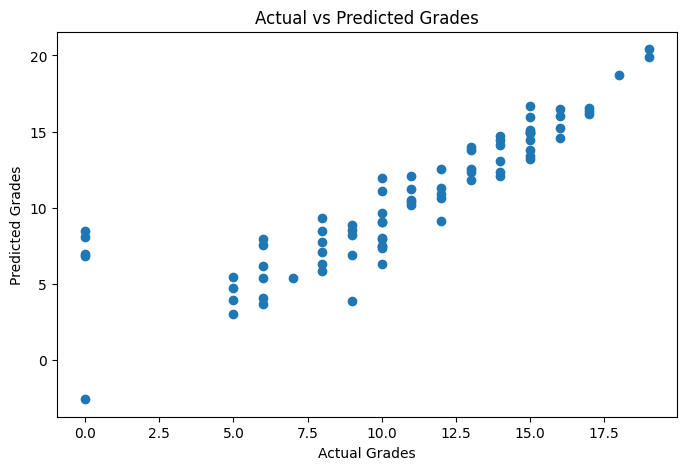

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Actual vs Predicted Grades")

plt.show()

# 15. Feature Importance

In [23]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
31,G2,0.954569
15,schoolsup,0.750961
1,sex,0.293869
23,famrel,0.289210
30,G1,0.206123
16,famsup,0.176043
25,goout,0.171814
12,traveltime,0.140033
20,higher,0.139570
6,Medu,0.115051


# 16. Save Model

In [25]:
import pickle

with open("student_performance_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model Saved Successfully")

Model Saved Successfully


# 17. Load Model Later

In [27]:
import pickle

with open("student_performance_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)